In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
N = 300

def rhs(t, F, params):
    """
    Right-hand side for the system F0..F8.
    F is ordered [F0, F1, F2, F3, F4, F5, F6, F7, F8].
    params is a dict containing: k_avg, lam1, lam2, mu, mu_bar
    """
    k = params['k_avg']
    lam1 = params['lam1']
    lam2 = params['lam2']
    mu = params['mu']
    mu_bar = params['mu_bar']
    
    F0, F1, F2, F3, F4, F5, F6, F7, F8 = F

    # common combinations
    comb1 = F1 + F4 + F7
    comb2 = F3 + F4 + F5

    dF0 = -k * lam1 * F0 * comb1 - k * lam2 * F0 * comb2
    dF1 = -F1 * mu - k * lam2 * F1 * comb2 + k * lam1 * F0 * comb1
    dF2 = F1 * mu - k * F2 * lam2 * comb2
    dF3 = -k * lam1 * F3 * comb1 - F3 * mu + k * lam2 * F0 * comb2
    dF4 = k * lam1 * F3 * comb1 + k * lam2 * F1 * comb2 - F4 * mu_bar
    dF5 = k * lam2 * F2 * comb2 - F5 * mu
    dF6 = -k * lam1 * F6 * comb1 + F3 * mu
    dF7 = k * lam1 * F6 * comb1 - F7 * mu
    dF8 = F4 * mu_bar + F7 * mu + F5 * mu

    return [dF0, dF1, dF2, dF3, dF4, dF5, dF6, dF7, dF8]

#Initial conditions
# Order: F0, F1, F2, F3, F4, F5, F6, F7, F8
y0 = [(N-2)/N, 1/N, 0, 1/N, 0, 0, 0, 0, 0]  

# --- Time span and evaluation times ---
t_span = (0.0, 50.0)               # start and end time
t_eval = np.linspace(t_span[0], t_span[1], 501)


In [3]:
L = 0.25
# --- Parameters  ---
params = {
    'k_avg': 10,    # <k>
    'lam1': L,     # lambda_1
    'lam2': L,     # lambda_2
    'mu': 1.0,       # mu
    'mu_bar': 1.0    # \bar{\mu}
}

In [4]:
# --- Solve ---
sol = solve_ivp(lambda t, y: rhs(t, y, params),
                t_span, y0, t_eval=t_eval, method='RK45', atol=1e-8, rtol=1e-6)

# Check success
if not sol.success:
    raise RuntimeError("ODE solver failed: " + sol.message)

In [5]:
i_A = sol.y[1] + sol.y[4] + sol.y[7]
i_B = sol.y[3] + sol.y[4] + sol.y[5]
J = i_A + i_B - sol.y[4]

In [6]:
def epidemic_duration(t, J, eps=0.0001):
    # define duration as first time after peak where J < eps
    t_peak_idx = np.argmax(J)
    J_tail = J[t_peak_idx:]
    t_tail = t[t_peak_idx:]

    below = np.where(J_tail < eps)[0]
    if len(below) == 0:
        return np.nan
    return t_tail[below[0]]

In [7]:
base_duration = epidemic_duration(sol.t, J, eps=0.01)

In [8]:
mu_bar_range = np.linspace(.1, 1, 1000)

In [9]:
Lrange = [0.2, 0.3, 0.4, 0.6]

In [10]:
ratios = []

In [11]:
for L in Lrange:
    ratio = []
    params = {
        'k_avg': 10,    # <k>
        'lam1': L,     # lambda_1
        'lam2': L,     # lambda_2
        'mu': 1.0,       # mu
        'mu_bar': 1    # \bar{\mu}
        }
    
    sol = solve_ivp(lambda t, y: rhs(t, y, params),
                    t_span, y0, t_eval=t_eval, method='RK45', atol=1e-8, rtol=1e-6)
    
    i_A = sol.y[1] + sol.y[4] + sol.y[7]
    i_B = sol.y[3] + sol.y[4] + sol.y[5]
    J = i_A + i_B - sol.y[4]
    
    base_duration = epidemic_duration(sol.t, J, eps=0.01)
    
    for m in mu_bar_range:
        params = {
        'k_avg': 10,    # <k>
        'lam1': L,     # lambda_1
        'lam2': L,     # lambda_2
        'mu': 1.0,       # mu
        'mu_bar': m    # \bar{\mu}
        }

        sol = solve_ivp(lambda t, y: rhs(t, y, params),
                    t_span, y0, t_eval=t_eval, method='RK45', atol=1e-8, rtol=1e-6)

        # Check success
        if not sol.success:
            raise RuntimeError("ODE solver failed: " + sol.message)

        i_A = sol.y[1] + sol.y[4] + sol.y[7]
        i_B = sol.y[3] + sol.y[4] + sol.y[5]
        J = i_A + i_B - sol.y[4]

        D = epidemic_duration(sol.t, J, eps=0.01)

        ratio.append(D/base_duration)
    ratios.append(ratio)

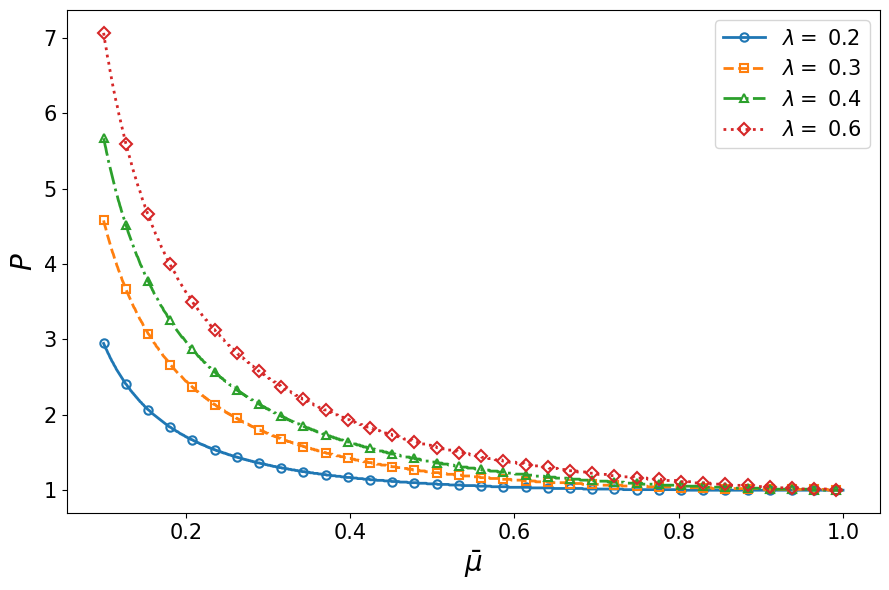

In [13]:
plt.figure(figsize=(9,6))

markers = ['o', 's', '^', 'D']   # circle, square, triangle, diamond
linestyles = ['-', '--', '-.', ':']


for L in range(len(Lrange)):
    plt.plot(
        mu_bar_range, ratios[L],
        label=rf'$\lambda =$ {Lrange[L]}',
        marker=markers[L],
        markevery=30,              
        markersize=6,
        linewidth=2,
        markerfacecolor='none',   
        markeredgewidth=1.5,
        linestyle=linestyles[L]
    )

plt.xlabel(r"$\bar{\mu}$", fontsize=20)
plt.ylabel(r"$P$", fontsize=20)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.legend(loc='best', fontsize=15)
plt.tight_layout()
plt.show()